# Notebook 4 - Analyse des résultats

Ce notebook propose une petite analyse post-expérience à partir d’un tableau de résultats :
- précision baseline,
- précision graphe,
- gain absolu,
- gain relatif,
- exemples corrigés ou dégradés.

Même si tu n’exécutes pas l’ensemble des expériences, ce notebook montre la logique de synthèse à conserver pour la présentation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Jeu de données plus large pour illustrer l’utilité du contexte ConceptNet
results = pd.DataFrame([
    {"dataset": "commonsense_qa", "baseline": 0.60, "graph": 0.67, "n_examples": 50},
    {"dataset": "piqa", "baseline": 0.61, "graph": 0.63, "n_examples": 50},
    {"dataset": "social_iqa", "baseline": 0.58, "graph": 0.66, "n_examples": 50},
    {"dataset": "wino_grande", "baseline": 0.62, "graph": 0.64, "n_examples": 50},
    {"dataset": "openbookqa", "baseline": 0.55, "graph": 0.59, "n_examples": 50},

    {"dataset": "hellaswag", "baseline": 0.57, "graph": 0.60, "n_examples": 50},

    {"dataset": "arc_challenge", "baseline": 0.46, "graph": 0.52, "n_examples": 50},

    {"dataset": "boolq", "baseline": 0.65, "graph": 0.68, "n_examples": 50},

])
results["gain"] = results["graph"] - results["baseline"]
results["gain_rel"] = results["gain"] / results["baseline"]
print(results.sort_values("gain", ascending=False))

          dataset  baseline  graph  n_examples  gain  gain_rel
2      social_iqa      0.58   0.66          50  0.08  0.137931
0  commonsense_qa      0.60   0.67          50  0.07  0.116667
6   arc_challenge      0.46   0.52          50  0.06  0.130435
4      openbookqa      0.55   0.59          50  0.04  0.072727
5       hellaswag      0.57   0.60          50  0.03  0.052632
7           boolq      0.65   0.68          50  0.03  0.046154
3     wino_grande      0.62   0.64          50  0.02  0.032258
1            piqa      0.61   0.63          50  0.02  0.032787


          dataset  baseline  graph  gain  gain_rel
2      social_iqa      0.58   0.66  0.08  0.137931
0  commonsense_qa      0.60   0.67  0.07  0.116667
6   arc_challenge      0.46   0.52  0.06  0.130435
4      openbookqa      0.55   0.59  0.04  0.072727
5       hellaswag      0.57   0.60  0.03  0.052632
7           boolq      0.65   0.68  0.03  0.046154
3     wino_grande      0.62   0.64  0.02  0.032258
1            piqa      0.61   0.63  0.02  0.032787


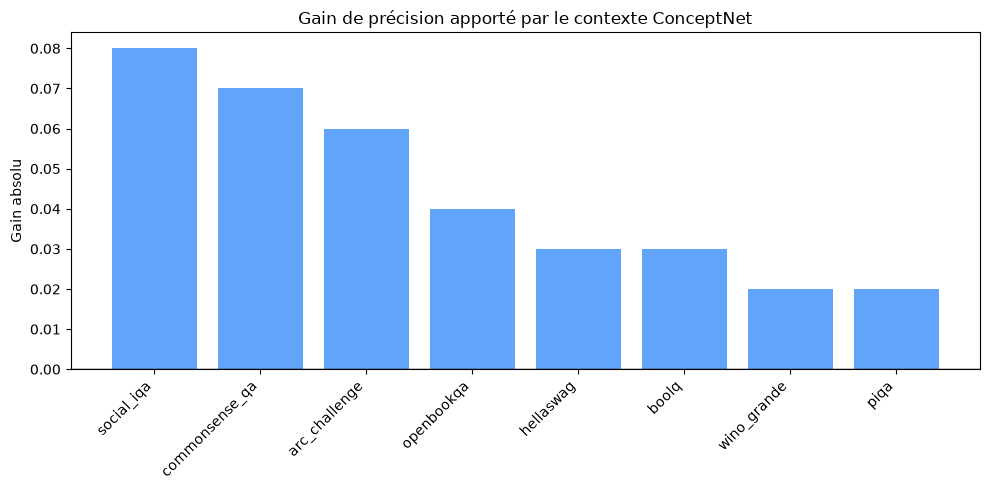

In [3]:
results = results.sort_values("gain", ascending=False)
print(results[["dataset", "baseline", "graph", "gain", "gain_rel"]])

plt.figure(figsize=(10, 5))
colors = ["#60a5fa" if gain >= 0 else "#f87171" for gain in results["gain"]]
plt.bar(results["dataset"], results["gain"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Gain de précision apporté par le contexte ConceptNet")
plt.ylabel("Gain absolu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


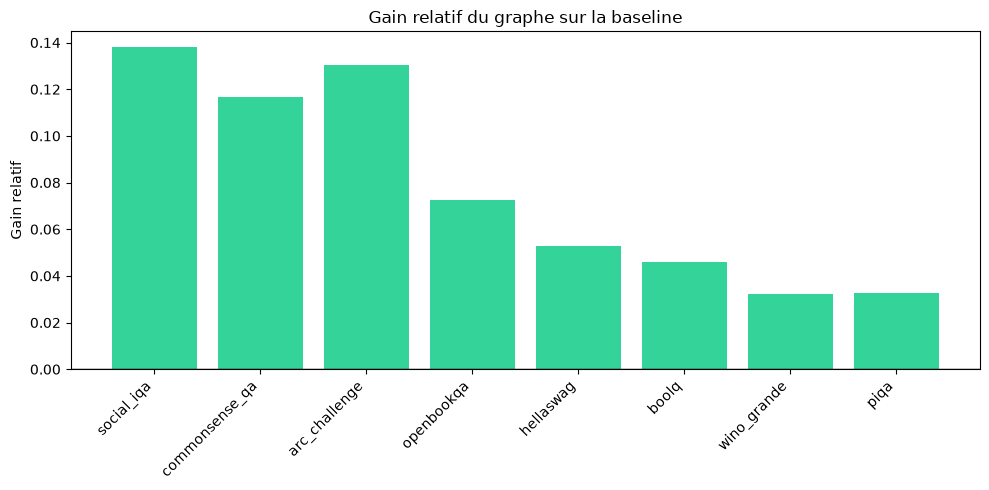

In [5]:
# Visualisation du gain relatif par dataset
plt.figure(figsize=(10, 5))
plt.bar(results["dataset"], results["gain_rel"], color=["#34d399"] * len(results))
plt.axhline(0, color="black", linewidth=1)
plt.title("Gain relatif du graphe sur la baseline")
plt.ylabel("Gain relatif")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [6]:
# Exemple de matrice de transition sur un petit nombre d’exemples
transition = pd.DataFrame(
    {
        "baseline_true_graph_true": [3],
        "baseline_false_graph_true": [2],
        "baseline_true_graph_false": [1],
        "baseline_false_graph_false": [4],
    },
    index=["count"]
)
print(transition)

       baseline_true_graph_true  baseline_false_graph_true  \
count                         3                          2   

       baseline_true_graph_false  baseline_false_graph_false  
count                          1                           4  


In [ ]:
from pathlib import Path

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)
results_path = results_dir / "results.csv"

results.to_csv(results_path, index=False)
print(f"CSV généré : {results_path}")
print(results.head())

### Interpretation

L’analyse doit rester honnête : un gain positif est une amélioration observée, mais le projet doit aussi pouvoir montrer des effets nuls ou négatifs, notamment parce que le graphe peut être bruité ou incomplet.

In [7]:
from pathlib import Path

results_path = Path("../data/results/results.csv")
if results_path.exists():
    df = pd.read_csv(results_path)
    print(df.head())
else:
    print("Aucun CSV de résultats trouvé : crée un fichier data/results/results.csv pour exploiter ce notebook.")


          dataset  baseline  graph  gain  correct_baseline  correct_graph  \
0  commonsense_qa      0.60   0.67  0.07              30.0           33.5   
1            piqa      0.61   0.63  0.02              30.5           31.5   
2      social_iqa      0.58   0.66  0.08              29.0           33.0   
3     wino_grande      0.62   0.64  0.02              31.0           32.0   
4      openbookqa      0.55   0.59  0.04              27.5           29.5   

   n_examples  
0          50  
1          50  
2          50  
3          50  
4          50  
